# LPF og HPF

Bode-plottene viser de målte frekvensresponser for lavpas- og højpasfilteret.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "grid.color": "#d6d9dd",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.72,
})

repo_root = Path.cwd()
if not (repo_root / "data/calibration/lpf_filter_bode.csv").exists():
    repo_root = repo_root.parent

plot_dir = repo_root / "data" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)


## LPF

Forstærkning i pasbånd: -0.02 dB
-3 dB grænsefrekvens: 1801.3 Hz
Gemte PNG til: /home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/plots/lpf_filter_bode.png


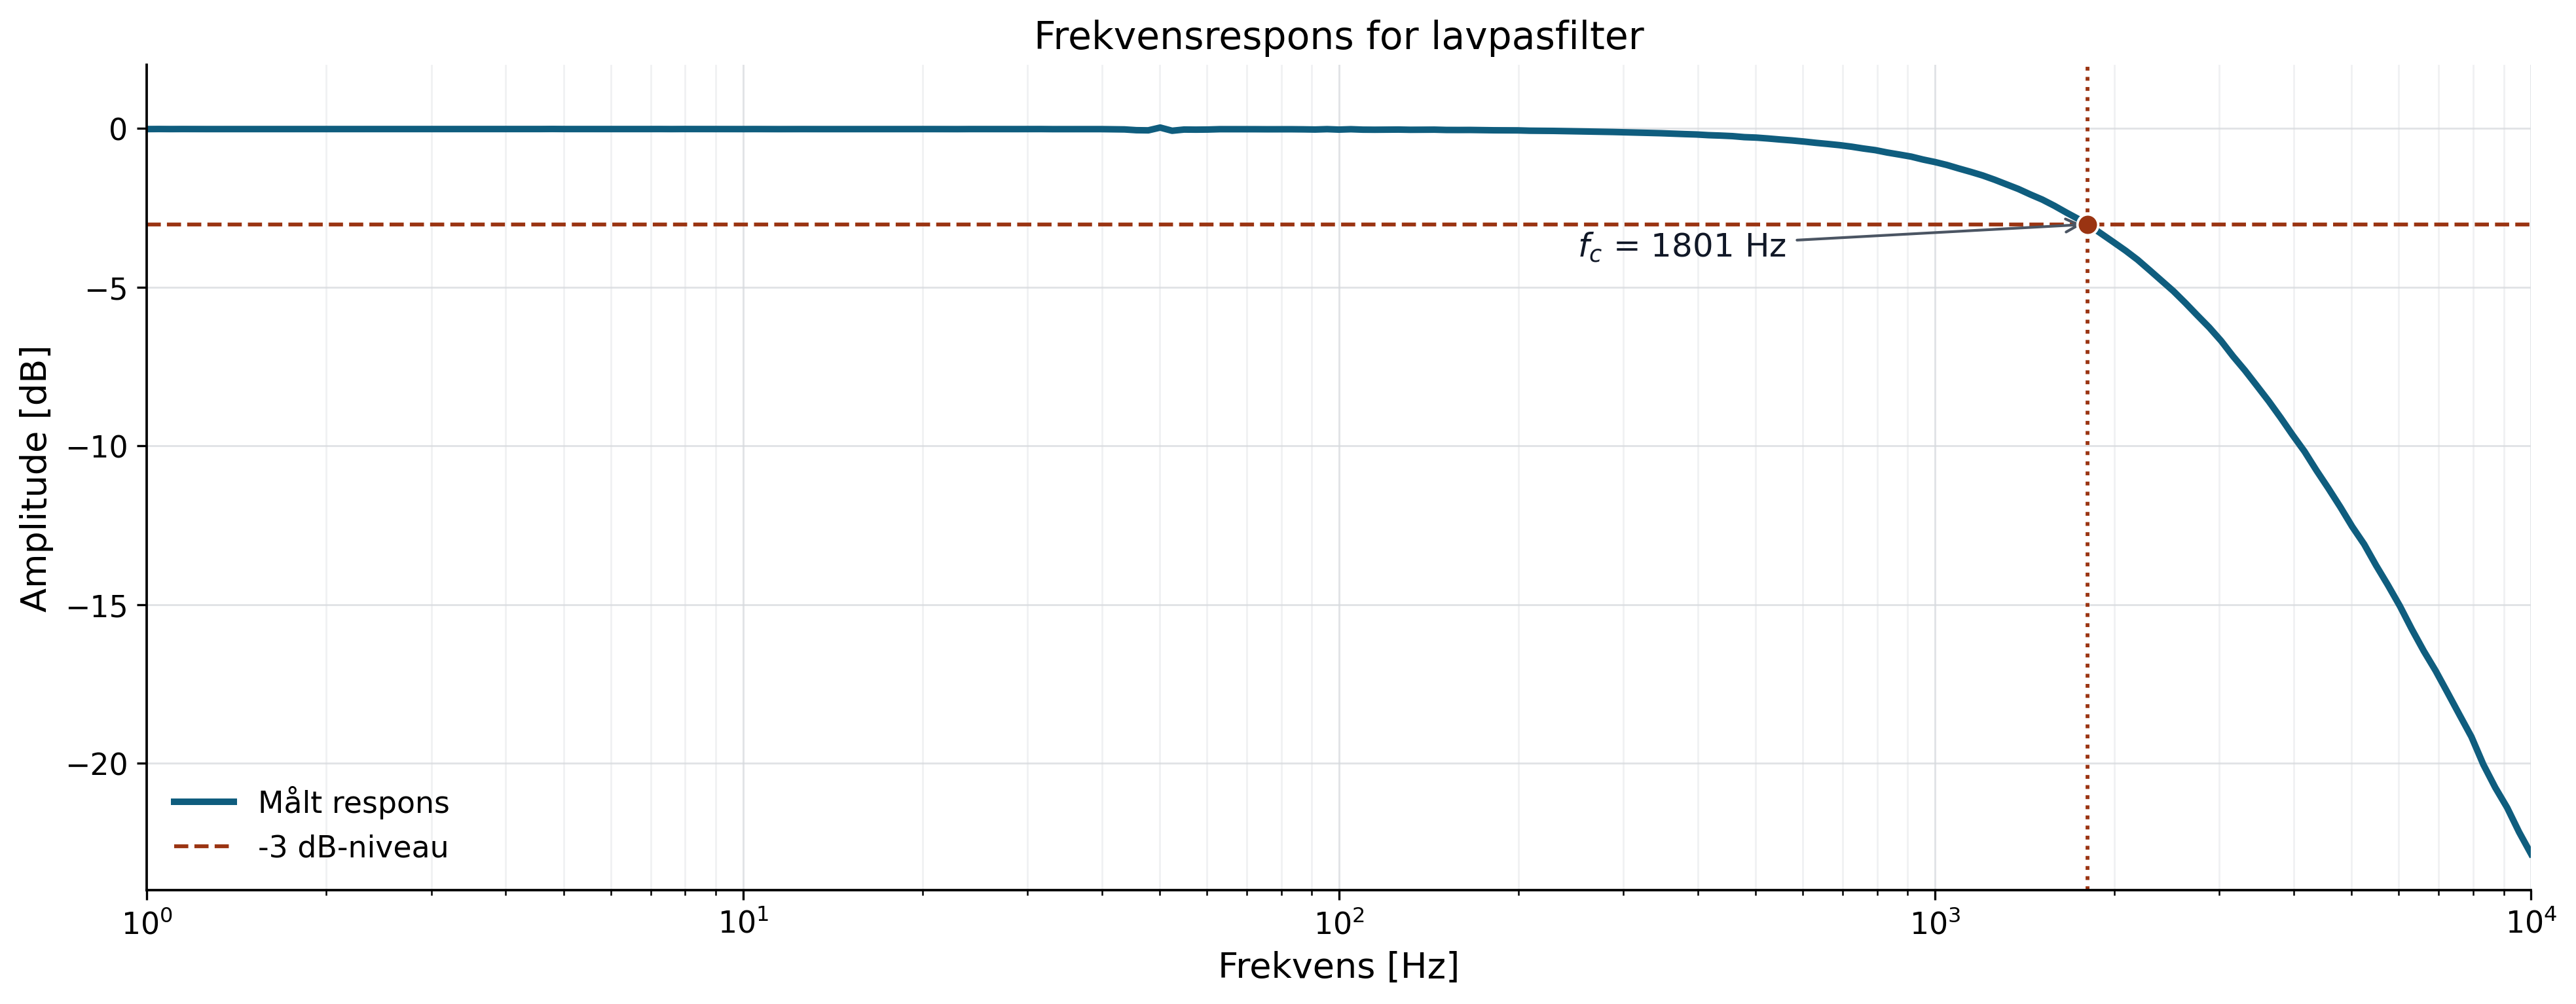

In [2]:
lpf = pd.read_csv(repo_root / "data/calibration/lpf_filter_bode.csv", comment="#")
lpf.columns = ["frequency_hz", "magnitude_db"]

lpf_frequency = lpf["frequency_hz"].to_numpy()
lpf_magnitude = lpf["magnitude_db"].to_numpy()

lpf_passband_gain_db = np.median(lpf_magnitude[:20])
lpf_cutoff_level_db = lpf_passband_gain_db - 3
lpf_crossings = np.flatnonzero(lpf_magnitude <= lpf_cutoff_level_db)

lpf_cutoff_hz = np.nan
if len(lpf_crossings):
    i = lpf_crossings[0]
    log_f0, log_f1 = np.log10(lpf_frequency[i - 1 : i + 1])
    mag0, mag1 = lpf_magnitude[i - 1 : i + 1]
    lpf_cutoff_log_hz = log_f0 + (lpf_cutoff_level_db - mag0) * (log_f1 - log_f0) / (mag1 - mag0)
    lpf_cutoff_hz = 10 ** lpf_cutoff_log_hz

fig, ax = plt.subplots(figsize=(13, 5), dpi=300, constrained_layout=True)

ax.semilogx(lpf_frequency, lpf_magnitude, color="#0f5d7e", linewidth=2.4, label="Målt respons")
ax.axhline(lpf_cutoff_level_db, color="#9a3412", linestyle="--", linewidth=1.4, label="-3 dB-niveau")
ax.axvline(lpf_cutoff_hz, color="#9a3412", linestyle=":", linewidth=1.4)
ax.scatter([lpf_cutoff_hz], [lpf_cutoff_level_db], s=58, color="#9a3412", edgecolor="white", linewidth=0.9, zorder=5)
ax.annotate(
    f"$f_c$ = {lpf_cutoff_hz:.0f} Hz",
    xy=(lpf_cutoff_hz, lpf_cutoff_level_db),
    xytext=(0.60, 0.78),
    textcoords="axes fraction",
    arrowprops={"arrowstyle": "->", "color": "#4b5563", "linewidth": 1.0},
    color="#111827",
    ha="left",
    va="center",
)

ax.set_title("Frekvensrespons for lavpasfilter")
ax.set_xlabel("Frekvens [Hz]")
ax.set_ylabel("Amplitude [dB]")
ax.set_xlim(lpf_frequency.min(), lpf_frequency.max())
ax.set_ylim(np.floor(lpf_magnitude.min() - 1), np.ceil(lpf_magnitude.max() + 1))
ax.grid(True, which="major")
ax.grid(True, which="minor", axis="x", alpha=0.35)
ax.legend(frameon=False, loc="lower left")

lpf_png_path = plot_dir / "lpf_filter_bode.png"
fig.savefig(lpf_png_path, bbox_inches="tight", dpi=300)

print(f"Forstærkning i pasbånd: {lpf_passband_gain_db:.2f} dB")
print(f"-3 dB grænsefrekvens: {lpf_cutoff_hz:.1f} Hz")
print(f"Gemte PNG til: {lpf_png_path}")

## HPF

Forstærkning i pasbånd: -0.02 dB
-3 dB grænsefrekvens: 0.8 Hz
Gemte PNG til: /home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/plots/hpf_filter_bode.png


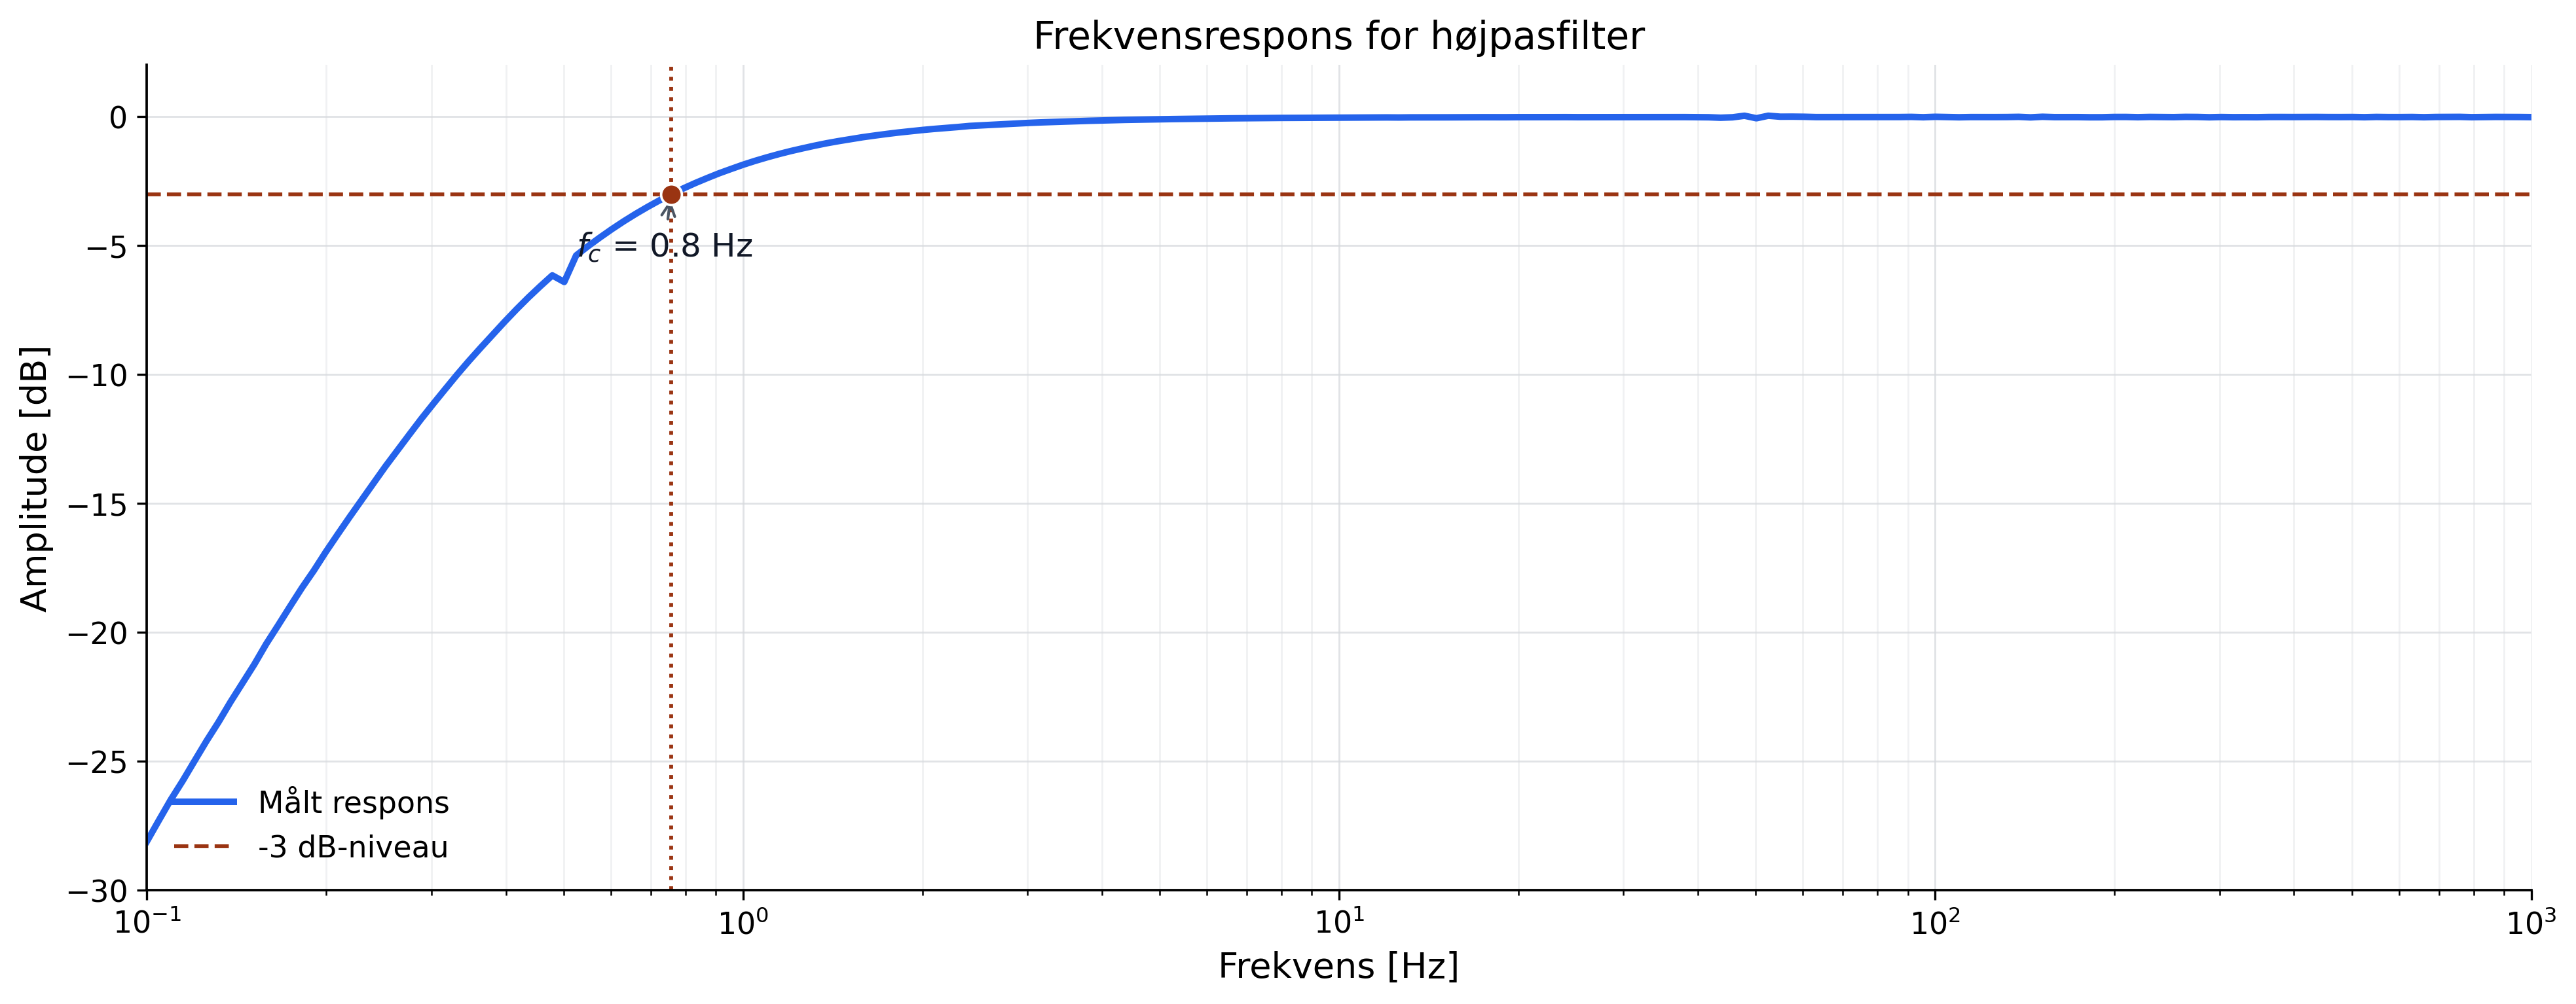

In [3]:
hpf = pd.read_csv(repo_root / "data/calibration/hpf_filter_bode.csv", comment="#")
hpf.columns = ["frequency_hz", "magnitude_db"]

hpf_frequency = hpf["frequency_hz"].to_numpy()
hpf_magnitude = hpf["magnitude_db"].to_numpy()

hpf_passband_gain_db = np.median(hpf_magnitude[-20:])
hpf_cutoff_level_db = hpf_passband_gain_db - 3
hpf_crossings = np.flatnonzero(hpf_magnitude >= hpf_cutoff_level_db)

hpf_cutoff_hz = np.nan
if len(hpf_crossings):
    i = hpf_crossings[0]
    log_f0, log_f1 = np.log10(hpf_frequency[i - 1 : i + 1])
    mag0, mag1 = hpf_magnitude[i - 1 : i + 1]
    hpf_cutoff_log_hz = log_f0 + (hpf_cutoff_level_db - mag0) * (log_f1 - log_f0) / (mag1 - mag0)
    hpf_cutoff_hz = 10 ** hpf_cutoff_log_hz

fig, ax = plt.subplots(figsize=(13, 5), dpi=300, constrained_layout=True)

ax.semilogx(hpf_frequency, hpf_magnitude, color="#2563eb", linewidth=2.4, label="Målt respons")
ax.axhline(hpf_cutoff_level_db, color="#9a3412", linestyle="--", linewidth=1.4, label="-3 dB-niveau")
ax.axvline(hpf_cutoff_hz, color="#9a3412", linestyle=":", linewidth=1.4)
ax.scatter([hpf_cutoff_hz], [hpf_cutoff_level_db], s=58, color="#9a3412", edgecolor="white", linewidth=0.9, zorder=5)
ax.annotate(
    f"$f_c$ = {hpf_cutoff_hz:.1f} Hz",
    xy=(hpf_cutoff_hz, hpf_cutoff_level_db),
    xytext=(0.18, 0.78),
    textcoords="axes fraction",
    arrowprops={"arrowstyle": "->", "color": "#4b5563", "linewidth": 1.0},
    color="#111827",
    ha="left",
    va="center",
)

ax.set_title("Frekvensrespons for højpasfilter")
ax.set_xlabel("Frekvens [Hz]")
ax.set_ylabel("Amplitude [dB]")
ax.set_xlim(hpf_frequency.min(), hpf_frequency.max())
ax.set_ylim(np.floor(hpf_magnitude.min() - 1), np.ceil(hpf_magnitude.max() + 1))
ax.grid(True, which="major")
ax.grid(True, which="minor", axis="x", alpha=0.35)
ax.legend(frameon=False, loc="lower left")

hpf_png_path = plot_dir / "hpf_filter_bode.png"
fig.savefig(hpf_png_path, bbox_inches="tight", dpi=300)

print(f"Forstærkning i pasbånd: {hpf_passband_gain_db:.2f} dB")
print(f"-3 dB grænsefrekvens: {hpf_cutoff_hz:.1f} Hz")
print(f"Gemte PNG til: {hpf_png_path}")